In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
path = '/content/drive/MyDrive/TFG/Data_prueba/esgcclbp'

In [ ]:
df_min = pd.read_csv(path+'/es1min.txt')
print(df_min.head(), len(df_min))
df_dia = pd.read_csv(path+'/es1dia.txt')
print(df_dia.head(), len(df_dia))

  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>   <OPEN>   <HIGH>    <LOW>  <CLOSE>  \
0       ES     I      20151209   70100  2063.00  2063.25  2063.00  2063.25   
1       ES     I      20151209   70200  2063.25  2063.50  2063.00  2063.50   
2       ES     I      20151209   70300  2063.25  2063.50  2063.25  2063.50   
3       ES     I      20151209   70400  2063.50  2063.50  2063.25  2063.50   
4       ES     I      20151209   70500  2063.25  2063.50  2063.25  2063.50   

   <VOL>  <OPENINT>  
0     60          0  
1     37          0  
2     26          0  
3     11          0  
4      6          0   2579332
  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>  <OPEN>  <HIGH>   <LOW>  <CLOSE>  \
0       ES     D      19970911       0  918.75  929.75  910.25   916.00   
1       ES     D      19970912       0  918.00  936.50  913.50   918.75   
2       ES     D      19970915       0  933.50  939.75  929.00   931.25   
3       ES     D      19970916       0  931.25  960.00  930.25   956.00   
4       ES     D

In [ ]:
from datetime import time

df_min['date_str'] = df_min['<DTYYYYMMDD>'].astype(str)
df_min['time_str'] = df_min['<TIME>'].astype(str).str.zfill(6)

# Crear datetime
df_min['datetime'] = pd.to_datetime(
    df_min['date_str'] + df_min['time_str'],
    format='%Y%m%d%H%M%S'
)
df_min['datetime'] = pd.to_datetime(df_min['datetime'])
df_min['date'] = df_min['datetime'].dt.normalize()
df_min['time'] = df_min['datetime'].dt.time

# Filtrar ventana 03:30–03:44 y ordenar
df_open_mins = df_min[
    (df_min['time'] >= time(15, 30)) &
    (df_min['time'] <= time(15, 44))
].copy()
df_open_mins = (
    df_open_mins
    .sort_values(['date', 'datetime'])
    .assign(min_id=lambda x: x.groupby('date').cumcount() + 1)
)
df_open_mins = df_open_mins.rename(columns={
    '<OPEN>': 'OPEN',
    '<HIGH>': 'HIGH',
    '<LOW>': 'LOW',
    '<CLOSE>': 'CLOSE',
    '<VOL>': 'VOL',
    '<OPENINT>': 'OPENINT'
})
df_open_mins.head()

,<TICKER>,<PER>,<DTYYYYMMDD>,<TIME>,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,date_str,time_str,datetime,date,time,min_id
508,ES,I,20151209,153000,2054.75,2055.75,2054.50,2054.50,2722,0,20151209,153000,2015-12-09 15:30:00,2015-12-09,15:30:00,1
509,ES,I,20151209,153100,2054.75,2056.00,2054.00,2055.75,13361,0,20151209,153100,2015-12-09 15:31:00,2015-12-09,15:31:00,2
510,ES,I,20151209,153200,2055.75,2057.25,2055.50,2056.75,10974,0,20151209,153200,2015-12-09 15:32:00,2015-12-09,15:32:00,3
511,ES,I,20151209,153300,2056.75,2057.50,2055.25,2057.00,11307,0,20151209,153300,2015-12-09 15:33:00,2015-12-09,15:33:00,4
512,ES,I,20151209,153400,2057.25,2058.25,2055.75,2056.00,8663,0,20151209,153400,2015-12-09 15:34:00,2015-12-09,15:34:00,5


In [ ]:
#Pivotar para tener formato diario
cols = [
    'date', 'min_id',
    'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL', 'OPENINT'
]
df_open_mins = df_open_mins[cols]
df_pivot = df_open_mins.pivot(
    index='date',
    columns='min_id',
    values=['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
)

# Aplanar columnas
df_pivot.columns = [
    f"m{min_id}_{var.lower()}"
    for var, min_id in df_pivot.columns
]

df_pivot = df_pivot.reset_index()
df_pivot

,date,m1_open,m2_open,m3_open,m4_open,m5_open,m6_open,m7_open,m8_open,m9_open,...,m6_vol,m7_vol,m8_vol,m9_vol,m10_vol,m11_vol,m12_vol,m13_vol,m14_vol,m15_vol
0,2015-12-09,2054.75,2054.75,2055.75,2056.75,2057.25,2056.00,2054.75,2057.75,2060.00,...,7813.0,7851.0,16967.0,12791.0,9258.0,8331.0,10475.0,11623.0,8201.0,6521.0
1,2015-12-10,2039.00,2038.75,2039.50,2038.00,2037.00,2037.00,2036.75,2037.50,2040.50,...,1485.0,2023.0,3146.0,1440.0,2281.0,1626.0,1616.0,869.0,2889.0,1150.0
2,2015-12-11,2017.25,2017.50,2017.25,2018.75,2019.00,2020.75,2020.25,2019.75,2018.50,...,6184.0,9881.0,6026.0,9881.0,6429.0,9502.0,4864.0,5729.0,5869.0,5905.0
3,2015-12-14,2005.00,2004.50,2004.75,2002.25,2004.25,2005.75,2008.75,2009.50,2008.50,...,10715.0,11052.0,12481.0,12814.0,4986.0,6077.0,6464.0,5238.0,6485.0,7764.0
4,2015-12-15,2031.00,2031.25,2031.75,2033.75,2036.25,2035.50,2034.50,2035.00,2035.00,...,8136.0,10897.0,8971.0,11341.0,6849.0,7731.0,11060.0,7622.0,6522.0,7347.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896,2023-09-13,4515.25,4515.25,4518.75,4523.00,4524.25,4520.00,4521.25,4523.25,4522.75,...,3084.0,3445.0,3206.0,3386.0,3390.0,2939.0,3052.0,2430.0,2719.0,3414.0
1897,2023-09-14,4540.25,4542.25,4538.25,4536.25,4539.00,4540.25,4537.25,4539.25,4539.25,...,4137.0,3791.0,3500.0,3335.0,3629.0,3784.0,2517.0,2329.0,2868.0,2158.0
1898,2023-09-15,4537.50,4537.00,4538.50,4537.25,4534.00,4535.50,4536.50,4537.25,4536.50,...,5680.0,4519.0,4487.0,4193.0,3301.0,4017.0,3040.0,3914.0,4130.0,4305.0
1899,2023-09-18,4494.25,4494.75,4495.75,4493.75,4493.25,4497.25,4498.50,4499.00,4499.00,...,4062.0,3207.0,3898.0,3578.0,3403.0,3136.0,4168.0,3589.0,4522.0,2777.0


In [ ]:
# Crear date (solo fecha, sin hora)
df_dia['date'] = pd.to_datetime(
    df_dia['<DTYYYYMMDD>'],
    format='%Y%m%d'
)

# Renombrar columnas OHLC diarias
df_dia = df_dia.rename(columns={
    '<OPEN>': 'D_OPEN',
    '<HIGH>': 'D_HIGH',
    '<LOW>': 'D_LOW',
    '<CLOSE>': 'D_CLOSE',
    '<VOL>': 'D_VOL',
    '<OPENINT>': 'D_OPENINT'
})
df_dia.drop(columns=['<DTYYYYMMDD>', '<PER>', '<TIME>', '<TICKER>'], inplace=True)
df_dia.head()

,D_OPEN,D_HIGH,D_LOW,D_CLOSE,D_VOL,D_OPENINT,date
0,918.75,929.75,910.25,916.00,11825,2909,1997-09-11
1,918.00,936.50,913.50,918.75,9759,4059,1997-09-12
2,933.50,939.75,929.00,931.25,8551,3818,1997-09-15
3,931.25,960.00,930.25,956.00,11749,5314,1997-09-16
4,956.00,962.50,951.50,956.00,10849,5516,1997-09-17


In [ ]:
df_final = df_dia.merge(
    df_pivot,
    on='date',
    how='left'
)
df_final.head()

,D_OPEN,D_HIGH,D_LOW,D_CLOSE,D_VOL,D_OPENINT,date,m1_open,m2_open,m3_open,...,m6_vol,m7_vol,m8_vol,m9_vol,m10_vol,m11_vol,m12_vol,m13_vol,m14_vol,m15_vol
0,918.75,929.75,910.25,916.00,11825,2909,1997-09-11,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,918.00,936.50,913.50,918.75,9759,4059,1997-09-12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,933.50,939.75,929.00,931.25,8551,3818,1997-09-15,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,931.25,960.00,930.25,956.00,11749,5314,1997-09-16,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,956.00,962.50,951.50,956.00,10849,5516,1997-09-17,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Columnas de minutos
cols_mins = [col for col in df_final.columns if col.startswith('m')]

# Crear columna temporal año
df_final['year'] = df_final['date'].dt.year

# Contar días con NaN por año
nan_summary = df_final.groupby('year').apply(
    lambda x: pd.Series({
        'total_dias': len(x),
        'dias_con_nan': x[cols_mins].isna().any(axis=1).sum(),
        'dias_completos': len(x) - x[cols_mins].isna().any(axis=1).sum()
    })
).reset_index()

print(nan_summary)

    year  total_dias  dias_con_nan  dias_completos
0   1997          78            78               0
1   1998         252           252               0
2   1999         252           252               0
3   2000         252           252               0
4   2001         249           249               0
5   2002         251           251               0
6   2003         254           254               0
7   2004         259           259               0
8   2005         258           258               0
9   2006         257           257               0
10  2007         259           259               0
11  2008         258           258               0
12  2009         257           257               0
13  2010         253           253               0
14  2011         252           252               0
15  2012         253           253               0
16  2013         252           252               0
17  2014         252           252               0
18  2015         254           

/tmp/ipykernel_366/3739915113.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nan_summary = df_final.groupby('year').apply(


No todos los años cuentan con valores de minutos. No podemos eliminar directamente los NaN porque entonces nos quedaríamos con pocos datos y sería poca muestra. Vamos a utilizar la siguiente estrategia:

Para los modelos que soportan NaN-> mantener. Se va a mantener los Nan para modelos como XGBoost porque lo pueden soportar y así comprobamos.
Para los modelos que no lo soportan -> Se reemplazará por la mediana. En caso de no obtener buenos resultados también se va a probar a eliminar las filas que tienen NaN.

# Cáclculo de parámetros

## Diario:

 displ= ((high+low)/2)- open  Para el día. Para ello guardamos los máximos, mínimos y de apertura en vectoeres.

In [ ]:
high = df_final['D_HIGH']
low = df_final['D_LOW']
open_ = df_final['D_OPEN']
close = df_final['D_CLOSE']
vol = df_final['D_VOL']

df_final['DISPLAY'] = ((high + low) / 2) - open_

Ahora se va a determinar BULLISH (es un valor que depende de displ, en caso de que displ sea positivo implica que es verdadero, si es falso es que es negativo)

In [ ]:
df_final['BULLISH'] = df_final['DISPLAY'] > 0

Definición del set de predictor en base a días anteriores:

1. El vactor de características incorporará variables que se corresponden con los 5 días anteriores. (Cómo la media o varianza).
2. Así mismo también incorporará variables del intervalo tomado al principio del día.

Variables:

- p5_close_open, p4_close_open, p3_close_open, p2_close_open, p1_close_open. Se corresponderán conn los vectores de características, p5 indica que es de 5 días antes, p4 de cuatro día antes... Se corresponde con el valor de cierre menos el valor de apertura.
- La media y la desviación típica de estos 5 valores en los días anteriores se incorpora también (p_close_open_mean y p_close_open_sd)

In [ ]:
df_final['CLOSE_OPEN'] = close - open_
for i in range(1, 6):
    df_final[f'p{i}_close_open'] = df_final['CLOSE_OPEN'].shift(i)

df_final['p_close_open_mean'] = df_final[
    [f'p{i}_close_open' for i in range(1, 6)]
].mean(axis=1)

df_final['p_close_open_sd'] = df_final[
    [f'p{i}_close_open' for i in range(1, 6)]
].std(axis=1)

for i in range(1, 6):
    df_final[f'p{i}_high_low'] = high.shift(i) - low.shift(i)

for i in range(1, 6):
    df_final[f'p{i}_is_bullish'] = df_final['BULLISH'].shift(i)

df_final['HINGE'] = (high - low) / 2

for i in range(1, 6):
    df_final[f'p{i}_HINGE'] = df_final['HINGE'].shift(i)

df_final['p_HINGE_mean'] = df_final[
    [f'p{i}_HINGE' for i in range(1, 6)]
].mean(axis=1)

df_final['p_HINGE_sd'] = df_final[
    [f'p{i}_HINGE' for i in range(1, 6)]
].std(axis=1)

for i in range(1, 6):
    df_final[f'p{i}_volume'] = vol.shift(i)

df_final['p_volume_mean'] = df_final[
    [f'p{i}_volume' for i in range(1, 6)]
].mean(axis=1)

df_final['p_volume_sd'] = df_final[
    [f'p{i}_volume' for i in range(1, 6)]
].std(axis=1)

for i in range(1, 6):
    df_final[f'p{i}_display'] = df_final['DISPLAY'].shift(i)

Los gaps representan la diferencia entre el precio de apertura del día y el cierre del día anterior.
Son fundamentales en trading porque condensan mucha información sobre sentimiento del mercado, reacción a noticias, y volatilidad nocturna.

Variables añadidas:

- prev_close → cierre del día anterior

- gap_abs → diferencia OPEN - CLOSE_prev

- gap_pct → tamaño del gap en porcentaje

- gap_dir → 1 si gap alcista, 0 si bajista

- gap_zscore → gap estandarizado (compara el gap actual con los últimos 20 días)

In [ ]:
# Cierre del día previo
df_final['prev_close'] = df_final['D_CLOSE'].shift(1)

# Gap absoluto: mide si el mercado abre por encima o por debajo del cierre previo
df_final['gap_abs'] = df_final['D_OPEN'] - df_final['prev_close']

# Gap porcentual: gap relativo al precio
df_final['gap_pct'] = df_final['gap_abs'] / df_final['prev_close']

# Dirección del gap: 1 si es alcista, 0 si es bajista
df_final['gap_dir'] = (df_final['gap_abs'] > 0).astype(int)

# Gap Z-score: gap actual comparado con su media y desviación de 20 días
df_final['gap_zscore'] = (
    df_final['gap_pct'] - df_final['gap_pct'].rolling(20).mean()
) / df_final['gap_pct'].rolling(20).std()

# Gaps de días anteriores (últimos 5 días)
for i in range(1, 6):
    df_final[f'p{i}_gap_abs'] = df_final['gap_abs'].shift(i)
    df_final[f'p{i}_gap_pct'] = df_final['gap_pct'].shift(i)
    df_final[f'p{i}_gap_dir'] = df_final['gap_dir'].shift(i)
    df_final[f'p{i}_gap_zscore'] = df_final['gap_zscore'].shift(i)


El True Range mide la volatilidad real del día considerando el rango de precios y los gaps.
El ATR (Average True Range) suaviza esa volatilidad en el tiempo.

Variables añadidas:

- true_range → volatilidad real del día

- ATR_5, ATR_10 → volatilidad reciente y suavizada

- ATR_zscore → volatilidad anormalmente alta o baja

In [ ]:
import numpy as np

# High y Low del día previo
df_final['prev_high'] = df_final['D_HIGH'].shift(1)
df_final['prev_low'] = df_final['D_LOW'].shift(1)

# True Range: máxima distancia relevante del día
tr1 = df_final['D_HIGH'] - df_final['D_LOW']
tr2 = (df_final['D_HIGH'] - df_final['prev_close']).abs()
tr3 = (df_final['D_LOW'] - df_final['prev_close']).abs()
df_final['true_range'] = np.maximum.reduce([tr1, tr2, tr3])

# ATR a 5 y 10 días
df_final['ATR_5'] = df_final['true_range'].rolling(5).mean()
df_final['ATR_10'] = df_final['true_range'].rolling(10).mean()

# ATR Z-score: volatilidad actual comparada con 20 días
df_final['ATR_zscore'] = (
    df_final['ATR_5'] - df_final['ATR_5'].rolling(20).mean()
) / df_final['ATR_5'].rolling(20).std()

for i in range(1, 6):
    # TR de hace i días
    df_final[f'lag{i}_true_range'] = df_final['true_range'].shift(i)

    # ATR de hace i días
    df_final[f'lag{i}_ATR_5'] = df_final['ATR_5'].shift(i)
    df_final[f'lag{i}_ATR_10'] = df_final['ATR_10'].shift(i)

    # ATR z-score de hace i días
    df_final[f'lag{i}_ATR_zscore'] = df_final['ATR_zscore'].shift(i)


Estas variables capturan si la volatilidad está expandiendo o contrayendo, y si hay tendencia reciente.

Variables añadidas:

- vol_regime → ATR_5 / ATR_10

- MA5, MA20 → medias móviles

- trend_MA_cross → cruce de medias (tendencia alcista =1)

In [ ]:
# Régimen de volatilidad: expansión (>1) o contracción (<1)
df_final['vol_regime'] = df_final['ATR_5'] / df_final['ATR_10']

# Medias móviles simple
df_final['MA5'] = df_final['D_CLOSE'].rolling(5).mean()
df_final['MA20'] = df_final['D_CLOSE'].rolling(20).mean()

# Señal de tendencia basada en cruce de medias
df_final['trend_MA_cross'] = (df_final['MA5'] > df_final['MA20']).astype(int)

# Lags de 5 días (solo información previa)
for i in range(1, 6):
    df_final[f'lag{i}_vol_regime'] = df_final['vol_regime'].shift(i)
    df_final[f'lag{i}_MA5'] = df_final['MA5'].shift(i)
    df_final[f'lag{i}_MA20'] = df_final['MA20'].shift(i)
    df_final[f'lag{i}_trend_MA_cross'] = df_final['trend_MA_cross'].shift(i)
df_final['log_ret'] = np.log(df_final['D_CLOSE'] / df_final['D_OPEN'])

/tmp/ipykernel_366/1082626466.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'lag{i}_vol_regime'] = df_final['vol_regime'].shift(i)
/tmp/ipykernel_366/1082626466.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'lag{i}_MA5'] = df_final['MA5'].shift(i)
/tmp/ipykernel_366/1082626466.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead

## Minutos

In [ ]:
open_cols  = [f'm{i}_open' for i in range(1, 16)]
close_cols = [f'm{i}_close' for i in range(1, 16)]
high_cols  = [f'm{i}_high' for i in range(1, 16)]
low_cols   = [f'm{i}_low' for i in range(1, 16)]
vol_cols   = [f'm{i}_vol' for i in range(1, 16)]
df_final['vol_15m_total'] = df_final[vol_cols].sum(axis=1)
df_final['vol_15m_mean'] = df_final[vol_cols].mean(axis=1)

# Precio apertura primer minuto y cierre último minuto
df_final['open_15m'] = df_final['m1_open']
df_final['close_15m'] = df_final['m15_close']
# Retorno logarítmico primeros 15 minutos
df_final['log_ret_15m'] = np.log(
    df_final['close_15m'] / df_final['open_15m']
)
# Rango de precios en los primeros 15 minutos
df_final['range_15m'] = (
    df_final[high_cols].max(axis=1) -
    df_final[low_cols].min(axis=1)
)
# Dirección del movimiento
df_final['dir_15m'] = np.sign(df_final['log_ret_15m'])


/tmp/ipykernel_366/1670737474.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['vol_15m_total'] = df_final[vol_cols].sum(axis=1)
/tmp/ipykernel_366/1670737474.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['vol_15m_mean'] = df_final[vol_cols].mean(axis=1)
/tmp/ipykernel_366/1670737474.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead

# Modelado

Vale, en primer lugar toca establecer probabilidades:

In [ ]:
#Primero de todo vamos a ordenar cronológicamente (just in case)
df_final = df_final.sort_values('date')


In [ ]:
df_model = df_final.copy()
df_model['y'] = (df_final['log_ret'] > 0).astype(int)

df_model.columns.to_list()

['D_OPEN',
 'D_HIGH',
 'D_LOW',
 'D_CLOSE',
 'D_VOL',
 'D_OPENINT',
 'date',
 'm1_open',
 'm2_open',
 'm3_open',
 'm4_open',
 'm5_open',
 'm6_open',
 'm7_open',
 'm8_open',
 'm9_open',
 'm10_open',
 'm11_open',
 'm12_open',
 'm13_open',
 'm14_open',
 'm15_open',
 'm1_high',
 'm2_high',
 'm3_high',
 'm4_high',
 'm5_high',
 'm6_high',
 'm7_high',
 'm8_high',
 'm9_high',
 'm10_high',
 'm11_high',
 'm12_high',
 'm13_high',
 'm14_high',
 'm15_high',
 'm1_low',
 'm2_low',
 'm3_low',
 'm4_low',
 'm5_low',
 'm6_low',
 'm7_low',
 'm8_low',
 'm9_low',
 'm10_low',
 'm11_low',
 'm12_low',
 'm13_low',
 'm14_low',
 'm15_low',
 'm1_close',
 'm2_close',
 'm3_close',
 'm4_close',
 'm5_close',
 'm6_close',
 'm7_close',
 'm8_close',
 'm9_close',
 'm10_close',
 'm11_close',
 'm12_close',
 'm13_close',
 'm14_close',
 'm15_close',
 'm1_vol',
 'm2_vol',
 'm3_vol',
 'm4_vol',
 'm5_vol',
 'm6_vol',
 'm7_vol',
 'm8_vol',
 'm9_vol',
 'm10_vol',
 'm11_vol',
 'm12_vol',
 'm13_vol',
 'm14_vol',
 'm15_vol',
 'year',

In [ ]:
cols_future = [
    'D_HIGH', 'D_LOW', 'D_CLOSE', 'D_VOL', 'D_OPENINT',
    'DISPLAY', 'BULLISH', 'CLOSE_OPEN',
    'HINGE',
    'true_range',
    'ATR_5', 'ATR_10', 'ATR_zscore',
    'vol_regime',
    'MA5', 'MA20',
    'trend_MA_cross',
    'prev_high', 'prev_low',
    'log_ret'
]

df_model = df_model.drop(
    columns=[c for c in cols_future if c in df_model.columns]
)

print("Columnas finales:", len(df_model.columns))
print(df_model.columns.to_list())


Columnas finales: 187
['D_OPEN', 'date', 'm1_open', 'm2_open', 'm3_open', 'm4_open', 'm5_open', 'm6_open', 'm7_open', 'm8_open', 'm9_open', 'm10_open', 'm11_open', 'm12_open', 'm13_open', 'm14_open', 'm15_open', 'm1_high', 'm2_high', 'm3_high', 'm4_high', 'm5_high', 'm6_high', 'm7_high', 'm8_high', 'm9_high', 'm10_high', 'm11_high', 'm12_high', 'm13_high', 'm14_high', 'm15_high', 'm1_low', 'm2_low', 'm3_low', 'm4_low', 'm5_low', 'm6_low', 'm7_low', 'm8_low', 'm9_low', 'm10_low', 'm11_low', 'm12_low', 'm13_low', 'm14_low', 'm15_low', 'm1_close', 'm2_close', 'm3_close', 'm4_close', 'm5_close', 'm6_close', 'm7_close', 'm8_close', 'm9_close', 'm10_close', 'm11_close', 'm12_close', 'm13_close', 'm14_close', 'm15_close', 'm1_vol', 'm2_vol', 'm3_vol', 'm4_vol', 'm5_vol', 'm6_vol', 'm7_vol', 'm8_vol', 'm9_vol', 'm10_vol', 'm11_vol', 'm12_vol', 'm13_vol', 'm14_vol', 'm15_vol', 'year', 'p1_close_open', 'p2_close_open', 'p3_close_open', 'p4_close_open', 'p5_close_open', 'p_close_open_mean', 'p_cl

In [ ]:
#Vale, empezamos con la parte de programar el modelo en base a probabilidades. Primer paso va a ser intentarlo con regresión logística.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, classification_report
import numpy as np
import pandas as pd

# Eliminar filas con NaN
df_model = df_model.dropna().copy()
print(df_model.columns.to_list())

# Separar X e y
X = df_model.drop(columns=['y', 'date'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir modelo:
model = LogisticRegression(solver='lbfgs')
model.fit(X_train_scaled, y_train)

# Probabilidades:
probs = model.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de clase 1 (subida)


# Definir intervalos
threshold_up = 0.7
threshold_down = 0.4

def label_from_prob(p):
    if p >= threshold_up:
        return 1   # subida
    elif p <= threshold_down:
        return 0   # bajada
    else:
        return -1  # neutral / no hacer nada

pred_labels = np.array([label_from_prob(p) for p in probs])

df_results = pd.DataFrame({
    'y_true': y_test,
    'prob_up': probs,
    'pred_label': pred_labels
})

print(df_results['pred_label'].value_counts())
df_results.head()

['D_OPEN', 'date', 'm1_open', 'm2_open', 'm3_open', 'm4_open', 'm5_open', 'm6_open', 'm7_open', 'm8_open', 'm9_open', 'm10_open', 'm11_open', 'm12_open', 'm13_open', 'm14_open', 'm15_open', 'm1_high', 'm2_high', 'm3_high', 'm4_high', 'm5_high', 'm6_high', 'm7_high', 'm8_high', 'm9_high', 'm10_high', 'm11_high', 'm12_high', 'm13_high', 'm14_high', 'm15_high', 'm1_low', 'm2_low', 'm3_low', 'm4_low', 'm5_low', 'm6_low', 'm7_low', 'm8_low', 'm9_low', 'm10_low', 'm11_low', 'm12_low', 'm13_low', 'm14_low', 'm15_low', 'm1_close', 'm2_close', 'm3_close', 'm4_close', 'm5_close', 'm6_close', 'm7_close', 'm8_close', 'm9_close', 'm10_close', 'm11_close', 'm12_close', 'm13_close', 'm14_close', 'm15_close', 'm1_vol', 'm2_vol', 'm3_vol', 'm4_vol', 'm5_vol', 'm6_vol', 'm7_vol', 'm8_vol', 'm9_vol', 'm10_vol', 'm11_vol', 'm12_vol', 'm13_vol', 'm14_vol', 'm15_vol', 'year', 'p1_close_open', 'p2_close_open', 'p3_close_open', 'p4_close_open', 'p5_close_open', 'p_close_open_mean', 'p_close_open_sd', 'p1_high

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,y_true,prob_up,pred_label
6157,0,0.021601,0
6158,0,0.063934,0
6159,1,0.630584,-1
6160,1,0.493666,-1
6161,1,0.496124,-1


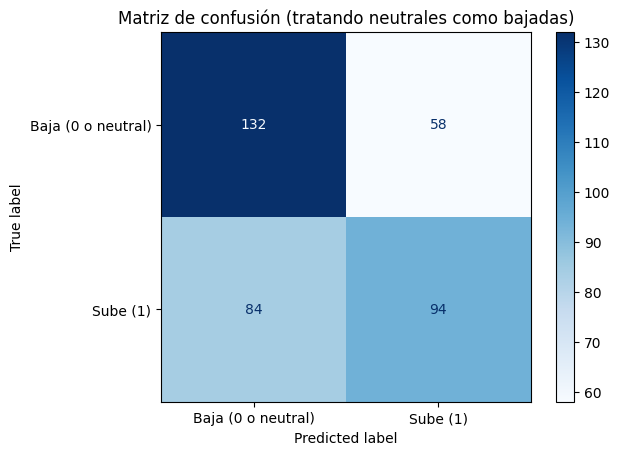

Reporte de clasificación (tratando neutrales como bajadas):
                  precision    recall  f1-score   support

Baja (0/neutral)       0.61      0.69      0.65       190
        Sube (1)       0.62      0.53      0.57       178

        accuracy                           0.61       368
       macro avg       0.61      0.61      0.61       368
    weighted avg       0.61      0.61      0.61       368


Reporte solo con predicciones claras (sin neutrales):
              precision    recall  f1-score   support

    Baja (0)       0.74      0.51      0.61       119
    Sube (1)       0.62      0.82      0.70       115

    accuracy                           0.66       234
   macro avg       0.68      0.66      0.66       234
weighted avg       0.68      0.66      0.65       234



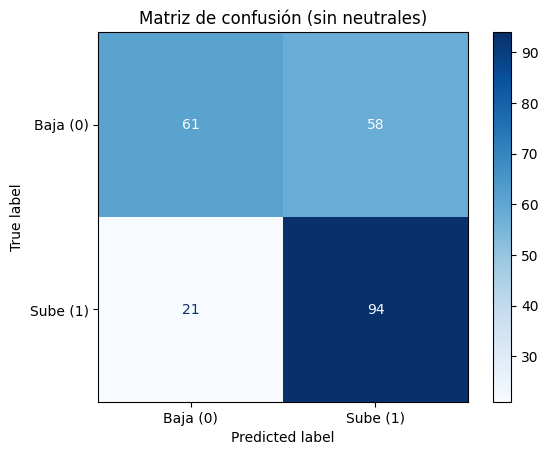

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
cm = confusion_matrix(y_test, np.where(pred_labels==-1, 0, pred_labels))  # -1 se trata como 0 para matriz
disp = ConfusionMatrixDisplay(cm, display_labels=['Baja (0 o neutral)', 'Sube (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión (tratando neutrales como bajadas)")
plt.show()

print("Reporte de clasificación (tratando neutrales como bajadas):")
print(classification_report(y_test, np.where(pred_labels==-1, 0, pred_labels), target_names=['Baja (0/neutral)', 'Sube (1)']))

# Evaluación sin clase neutral
mask = pred_labels != -1
y_true_eval = y_test[mask]
y_pred_eval = pred_labels[mask]

print("\nReporte solo con predicciones claras (sin neutrales):")
print(classification_report(y_true_eval, y_pred_eval, target_names=['Baja (0)', 'Sube (1)']))

# Matriz de confusión sin neutrales
cm_clear = confusion_matrix(y_true_eval, y_pred_eval)
disp_clear = ConfusionMatrixDisplay(cm_clear, display_labels=['Baja (0)', 'Sube (1)'])
disp_clear.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión (sin neutrales)")
plt.show()


=== UMBRALES MAE (Stop-Loss sugerido) ===
  P25 (stop ajustado):  -35.88 puntos
  P50 (stop moderado):  -19.38 puntos
  P75 (stop amplio):    -7.56 puntos

=== UMBRALES MFE (Take-Profit sugerido) ===
  P25 (target conservador): 24.62 puntos
  P50 (target moderado):    46.88 puntos
  P75 (target ambicioso):   75.62 puntos


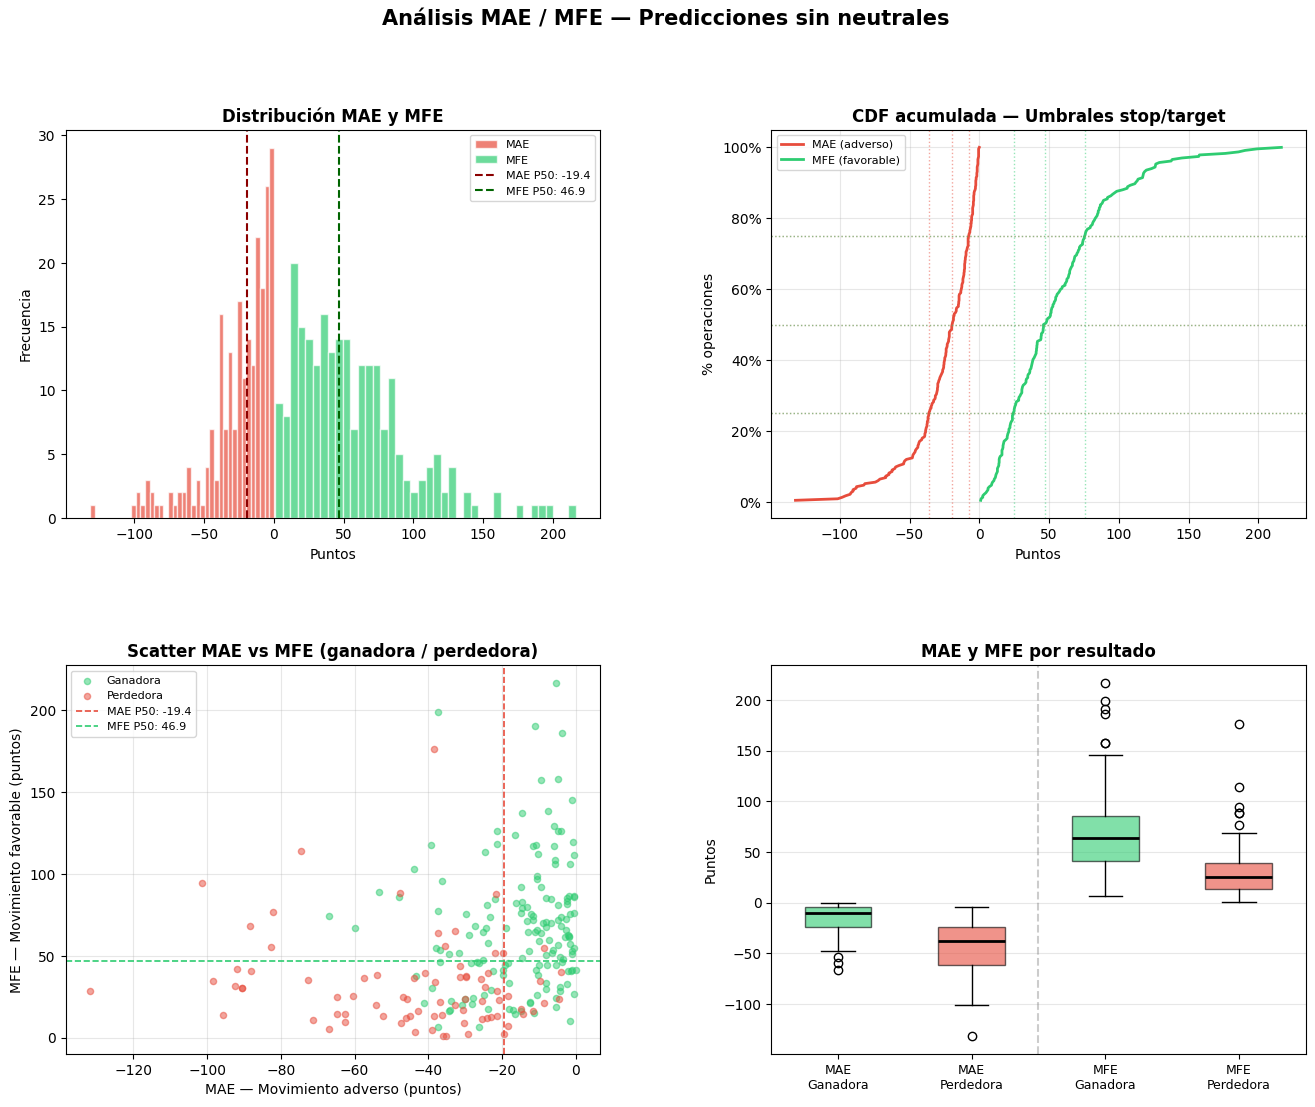

Gráfica guardada como 'mae_mfe_analysis.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# Solo predicciones claras (sin neutrales)
mask = pred_labels != -1
df_eval = df_results[mask].copy()

# Recuperar columnas de precio alineadas con el test set
df_prices = df_final.loc[y_test.index, ['D_OPEN', 'D_HIGH', 'D_LOW', 'D_CLOSE']]
df_eval = df_eval.join(df_prices)

# Dirección de la operación según predicción
df_eval['direction'] = df_eval['pred_label'].map({1: 'long', 0: 'short'})

# MAE: movimiento máximo en contra (siempre negativo o cero)
df_eval['MAE'] = np.where(
    df_eval['direction'] == 'long',
    df_eval['D_LOW']  - df_eval['D_OPEN'],   # largo: baja duele
    df_eval['D_OPEN'] - df_eval['D_HIGH']    # corto: sube duele
)

# MFE: movimiento máximo a favor (siempre positivo o cero)
df_eval['MFE'] = np.where(
    df_eval['direction'] == 'long',
    df_eval['D_HIGH'] - df_eval['D_OPEN'],   # largo: sube beneficia
    df_eval['D_OPEN'] - df_eval['D_LOW']     # corto: baja beneficia
)

# Resultado final al cierre
df_eval['result'] = np.where(
    df_eval['direction'] == 'long',
    df_eval['D_CLOSE'] - df_eval['D_OPEN'],
    df_eval['D_OPEN']  - df_eval['D_CLOSE']
)

df_eval['outcome'] = np.where(df_eval['result'] > 0, 'Ganadora', 'Perdedora')


mae_p25 = np.percentile(df_eval['MAE'], 25)   # stop ajustado
mae_p50 = np.percentile(df_eval['MAE'], 50)   # stop moderado
mae_p75 = np.percentile(df_eval['MAE'], 75)   # stop amplio

mfe_p25 = np.percentile(df_eval['MFE'], 25)
mfe_p50 = np.percentile(df_eval['MFE'], 50)
mfe_p75 = np.percentile(df_eval['MFE'], 75)

print("=== UMBRALES MAE (Stop-Loss sugerido) ===")
print(f"  P25 (stop ajustado):  {mae_p25:.2f} puntos")
print(f"  P50 (stop moderado):  {mae_p50:.2f} puntos")
print(f"  P75 (stop amplio):    {mae_p75:.2f} puntos")

print("\n=== UMBRALES MFE (Take-Profit sugerido) ===")
print(f"  P25 (target conservador): {mfe_p25:.2f} puntos")
print(f"  P50 (target moderado):    {mfe_p50:.2f} puntos")
print(f"  P75 (target ambicioso):   {mfe_p75:.2f} puntos")

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Análisis MAE / MFE — Predicciones sin neutrales', fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

colors = {'Ganadora': '#2ecc71', 'Perdedora': '#e74c3c'}

# ── Gráfica 1: Histogramas MAE y MFE ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_eval['MAE'], bins=40, color='#e74c3c', alpha=0.7, edgecolor='white', label='MAE')
ax1.hist(df_eval['MFE'], bins=40, color='#2ecc71', alpha=0.7, edgecolor='white', label='MFE')
ax1.axvline(mae_p50, color='darkred',   linestyle='--', lw=1.5, label=f'MAE P50: {mae_p50:.1f}')
ax1.axvline(mfe_p50, color='darkgreen', linestyle='--', lw=1.5, label=f'MFE P50: {mfe_p50:.1f}')
ax1.set_title('Distribución MAE y MFE', fontweight='bold')
ax1.set_xlabel('Puntos')
ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=8)

# ── Gráfica 2: CDF acumulada (la más útil para umbrales) ──────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mae_sorted = np.sort(df_eval['MAE'])
mfe_sorted = np.sort(df_eval['MFE'])
cdf = np.arange(1, len(mae_sorted) + 1) / len(mae_sorted)

ax2.plot(mae_sorted, cdf, color='#e74c3c', lw=2, label='MAE (adverso)')
ax2.plot(mfe_sorted, cdf, color='#2ecc71', lw=2, label='MFE (favorable)')

for p, val in [(0.25, mae_p25), (0.50, mae_p50), (0.75, mae_p75)]:
    ax2.axhline(p, color='#e74c3c', linestyle=':', alpha=0.5, lw=1)
    ax2.axvline(val, color='#e74c3c', linestyle=':', alpha=0.5, lw=1)
for p, val in [(0.25, mfe_p25), (0.50, mfe_p50), (0.75, mfe_p75)]:
    ax2.axhline(p, color='#2ecc71', linestyle=':', alpha=0.5, lw=1)
    ax2.axvline(val, color='#2ecc71', linestyle=':', alpha=0.5, lw=1)

ax2.set_title('CDF acumulada — Umbrales stop/target', fontweight='bold')
ax2.set_xlabel('Puntos')
ax2.set_ylabel('% operaciones')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Gráfica 3: Scatter MAE vs MFE coloreado por resultado ─────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for outcome, grp in df_eval.groupby('outcome'):
    ax3.scatter(grp['MAE'], grp['MFE'],
                c=colors[outcome], alpha=0.5, s=20, label=outcome)

ax3.axvline(mae_p50, color='#e74c3c', linestyle='--', lw=1.2, label=f'MAE P50: {mae_p50:.1f}')
ax3.axhline(mfe_p50, color='#2ecc71', linestyle='--', lw=1.2, label=f'MFE P50: {mfe_p50:.1f}')
ax3.set_title('Scatter MAE vs MFE (ganadora / perdedora)', fontweight='bold')
ax3.set_xlabel('MAE — Movimiento adverso (puntos)')
ax3.set_ylabel('MFE — Movimiento favorable (puntos)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# ── Gráfica 4: Box MAE y MFE por resultado ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
data_box = [
    df_eval.loc[df_eval['outcome'] == 'Ganadora', 'MAE'],
    df_eval.loc[df_eval['outcome'] == 'Perdedora', 'MAE'],
    df_eval.loc[df_eval['outcome'] == 'Ganadora', 'MFE'],
    df_eval.loc[df_eval['outcome'] == 'Perdedora', 'MFE'],
]
bp = ax4.boxplot(data_box, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', lw=2))

box_colors = ['#2ecc71', '#e74c3c', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax4.set_xticks([1, 2, 3, 4])
ax4.set_xticklabels(['MAE\nGanadora', 'MAE\nPerdedora', 'MFE\nGanadora', 'MFE\nPerdedora'], fontsize=9)
ax4.set_title('MAE y MFE por resultado', fontweight='bold')
ax4.set_ylabel('Puntos')
ax4.axvline(2.5, color='gray', linestyle='--', alpha=0.4)
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('mae_mfe_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'mae_mfe_analysis.png'")